<a href="https://colab.research.google.com/github/s32ol/predictive-maintenance-ai4i/blob/main/02_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)
df.shape

(10000, 14)

In [2]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
print(df['Machine failure'].value_counts())
print()
print(df['Machine failure'].value_counts(normalize=True))

Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [5]:
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

df[sensor_cols].corr().round(2)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Air temperature [K],1.00,0.88,0.02,-0.01,0.01
Process temperature [K],0.88,1.00,0.02,-0.01,0.01
Rotational speed [rpm],0.02,0.02,1.00,-0.88,0.00
Torque [Nm],-0.01,-0.01,-0.88,1.00,-0.00
Tool wear [min],0.01,0.01,0.00,-0.00,1.00


In [6]:
df.groupby('Type')['Machine failure'].mean()

,Machine failure
Type,
H,0.020937
L,0.039167
M,0.027694


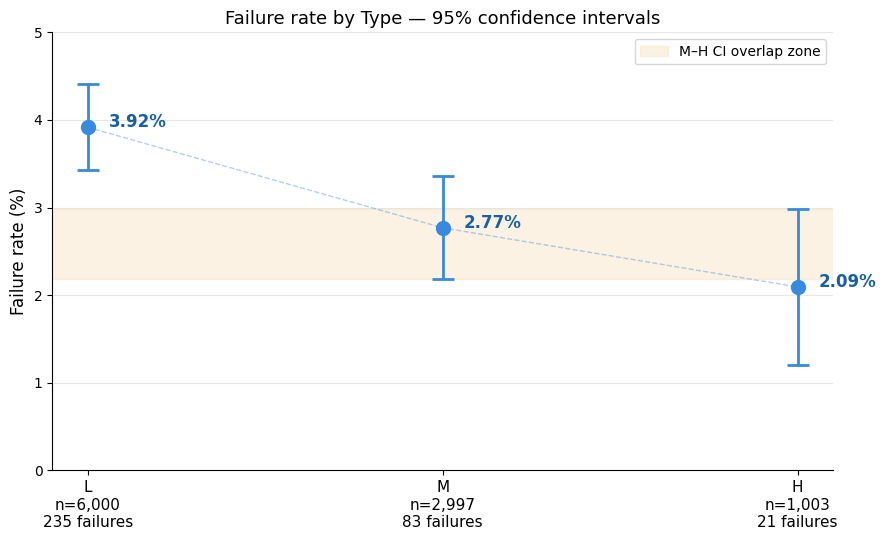

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Compute rates, sample sizes, and failure counts
stats = df.groupby('Type')['Machine failure'].agg(['mean', 'count', 'sum'])
stats = stats.reindex(['L', 'M', 'H'])  # enforce L → M → H order

p = stats['mean'].values
n = stats['count'].values
failures = stats['sum'].values
ci_95 = 1.96 * np.sqrt(p * (1 - p) / n)  # 95% CI half-width

# Build the chart
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(3)
types = ['L', 'M', 'H']

# Points with error bars
ax.errorbar(x, p * 100, yerr=ci_95 * 100, fmt='o',
            color='#378ADD', ecolor='#378ADD',
            capsize=8, capthick=2, markersize=10, linewidth=2)

# Dashed trend line
ax.plot(x, p * 100, '--', color='#378ADD', alpha=0.4, linewidth=1)

# Rate labels next to each point
for i in range(3):
    ax.annotate(f'{p[i]*100:.2f}%', (x[i], p[i] * 100),
                xytext=(15, 0), textcoords='offset points',
                fontsize=12, color='#185FA5', fontweight='bold')

# M-H CI overlap zone (the noisy region)
m_low, m_high = (p[1] - ci_95[1]) * 100, (p[1] + ci_95[1]) * 100
h_low, h_high = (p[2] - ci_95[2]) * 100, (p[2] + ci_95[2]) * 100
overlap_low = max(m_low, h_low)
overlap_high = min(m_high, h_high)
if overlap_high > overlap_low:
    ax.axhspan(overlap_low, overlap_high, alpha=0.13, color='#EF9F27',
               label='M–H CI overlap zone')

ax.set_xticks(x)
ax.set_xticklabels([f"{t}\nn={n[i]:,}\n{failures[i]} failures"
                    for i, t in enumerate(types)], fontsize=11)
ax.set_ylabel('Failure rate (%)', fontsize=12)
ax.set_title('Failure rate by Type — 95% confidence intervals', fontsize=13)
ax.set_ylim(0, 5)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
# Check: does Machine failure equal the OR of the 5 mode flags, row by row?
mode_or = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].any(axis=1).astype(int)

exact_match = (mode_or == df['Machine failure']).all()
print(f"Perfect match across all 10,000 rows? {exact_match}")

if not exact_match:
    mismatches = df[mode_or != df['Machine failure']]
    print(f"\nMismatching rows: {len(mismatches)} out of {len(df)} "
          f"({len(mismatches)/len(df)*100:.3f}%)")
    print("\nThe mismatches:")
    print(mismatches[['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']])

Perfect match across all 10,000 rows? False

Mismatching rows: 27 out of 10000 (0.270%)

The mismatches:
      Machine failure  TWF  HDF  PWF  OSF  RNF
1221                0    0    0    0    0    1
1302                0    0    0    0    0    1
1437                1    0    0    0    0    0
1748                0    0    0    0    0    1
2072                0    0    0    0    0    1
2559                0    0    0    0    0    1
2749                1    0    0    0    0    0
3065                0    0    0    0    0    1
3452                0    0    0    0    0    1
4044                1    0    0    0    0    0
4684                1    0    0    0    0    0
5471                0    0    0    0    0    1
5489                0    0    0    0    0    1
5495                0    0    0    0    0    1
5509                0    0    0    0    0    1
5536                1    0    0    0    0    0
5553                0    0    0    0    0    1
5639                0    0    0    0    0    1
59